In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("RE 2026.xlsx")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (20000, 12)
    Sale_ID  Sale_Date  Year Quarter     Month    Weekday             State  \
0  RE000001 2025-01-31  2025      Q1   January     Friday       Maharashtra   
1  RE000002 2022-07-09  2022      Q3      July   Saturday           Gujarat   
2  RE000003 2025-11-12  2025      Q4  November  Wednesday         Karnataka   
3  RE000004 2023-06-05  2023      Q2      June     Monday  Himachal Pradesh   
4  RE000005 2023-10-05  2023      Q4   October   Thursday        Tamil Nadu   

   Revenue  Petrol_Price  Inflation_Rate  Repo_Rate      Variant  
0   225043        105.74            5.36       4.87  Classic 350  
1   207048        108.30            7.08       4.52   Bullet 350  
2   196439        106.19            6.02       6.90   Bullet 350  
3   335012        111.89            6.24       6.66    Himalayan  
4   208069        118.29            6.08       6.08   Bullet 350  


In [3]:
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"])

df["Day"] = df["Sale_Date"].dt.day
df["Month_Num"] = df["Sale_Date"].dt.month

In [4]:
encoders = {}

categorical_cols = [
    "Quarter",
    "Month",
    "Weekday",
    "State",
    "Variant"
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


In [5]:
X = df[
    [
        "Year",
        "Quarter",
        "Month",
        "Weekday",
        "State",
        "Petrol_Price",
        "Inflation_Rate",
        "Repo_Rate",
        "Variant",
        "Day",
        "Month_Num"
    ]
]

y = df["Revenue"]


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [7]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [8]:
y_pred = rf.predict(X_test)

In [9]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))


========== MODEL PERFORMANCE ==========
MAE : 9003.28
RMSE: 11036.79
R² Score: 0.9596



Feature Importance
           Feature  Importance
8          Variant    0.978518
5     Petrol_Price    0.004207
7        Repo_Rate    0.003886
6   Inflation_Rate    0.003882
9              Day    0.002624
10       Month_Num    0.001790
3          Weekday    0.001505
4            State    0.001359
0             Year    0.001000
2            Month    0.000672
1          Quarter    0.000558


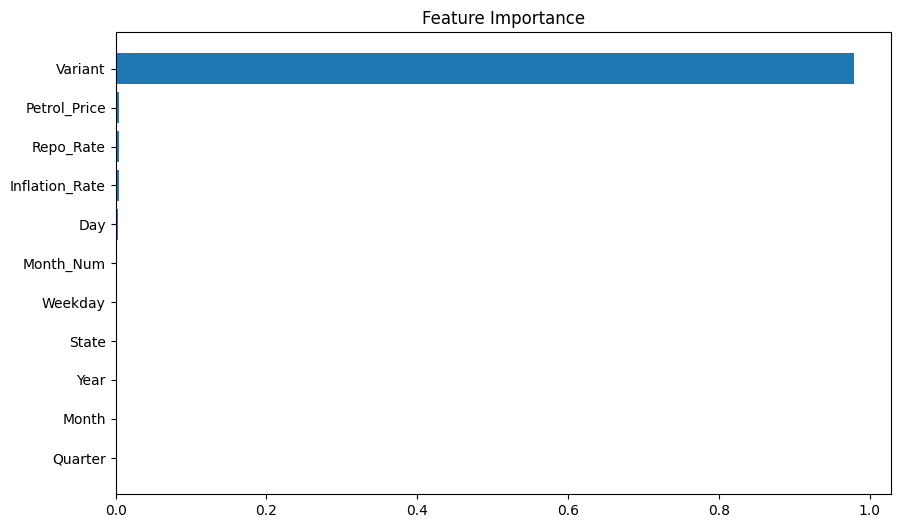

In [10]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [12]:

avg_petrol = df["Petrol_Price"].mean()
avg_inflation = df["Inflation_Rate"].mean()
avg_repo = df["Repo_Rate"].mean()

variants = encoders["Variant"].classes_

prediction_rows = []

for variant in variants:

    variant_encoded = encoders["Variant"].transform([variant])[0]

    temp = pd.DataFrame({
        "Year":[2026],
        "Quarter":[0],
        "Month":[0],
        "Weekday":[0],
        "State":[0],
        "Petrol_Price":[avg_petrol],
        "Inflation_Rate":[avg_inflation],
        "Repo_Rate":[avg_repo],
        "Variant":[variant_encoded],
        "Day":[15],
        "Month_Num":[6]
    })

    pred = rf.predict(temp)[0]

    prediction_rows.append(
        [variant, round(pred,2)]
    )

In [13]:
prediction_df = pd.DataFrame(
    prediction_rows,
    columns=["Variant","Predicted_Revenue_2026"]
)

print("\n========== VARIANT WISE 2026 SALES ==========")
print(prediction_df)


========== VARIANT WISE 2026 SALES ==========
              Variant  Predicted_Revenue_2026
0          Bullet 350               205542.53
1         Classic 350               229915.99
2  Continental GT 650               240220.23
3           Himalayan               330430.97
4          Hunter 350               177786.77
5     Interceptor 650               349264.16


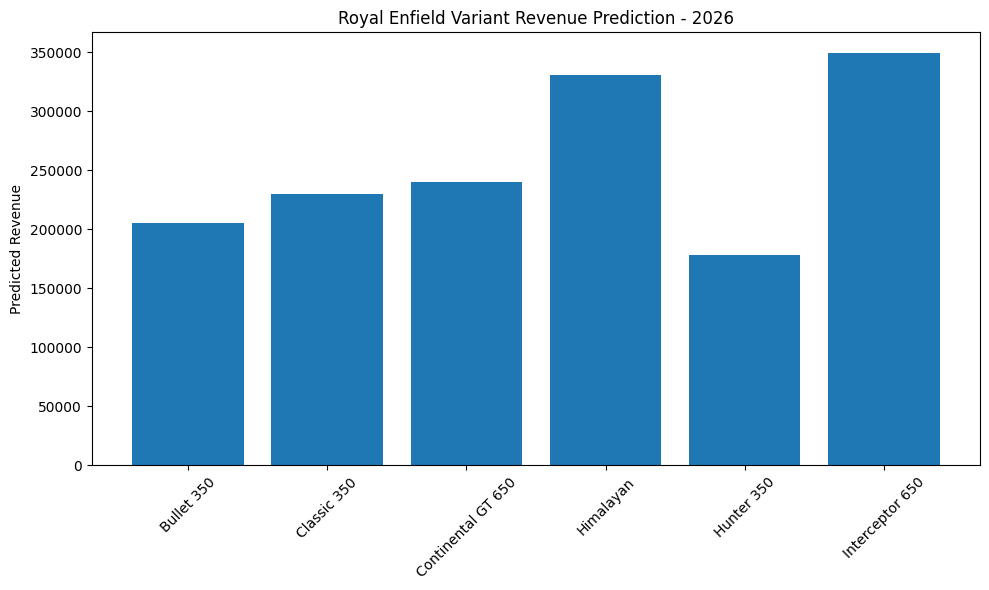

In [14]:
plt.figure(figsize=(10,6))
plt.bar(
    prediction_df["Variant"],
    prediction_df["Predicted_Revenue_2026"]
)

plt.title("Royal Enfield Variant Revenue Prediction - 2026")
plt.xticks(rotation=45)
plt.ylabel("Predicted Revenue")
plt.tight_layout()
plt.show()


In [15]:
total_2026 = prediction_df[
    "Predicted_Revenue_2026"
].sum()

print("\n================================")
print("TOTAL PREDICTED REVENUE 2026")
print("₹ {:,.0f}".format(total_2026))
print("================================")


TOTAL PREDICTED REVENUE 2026
₹ 1,533,161
